<a href="https://colab.research.google.com/github/juliaeworthington/dmdr/blob/master/tutorials/tutorial_dmdr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMDr (Dynamic Mode Decomposition for R)

This tutorial goes through the various functions contained in the DMDr package. Let's start by installing the DMDr package from the Github. This can take a long time because of the large amount of other packages installed with DMDr.

In [2]:
install.packages("remotes")
library(remotes)
install_github("juliaeworthington/dmdr")
library(pracma) # we need pracma to create our toy data set
library(dmdr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)





── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmp9eyzb1/remotesd9bc67dfeb2f/juliaeworthington-dmdr-074c22d/DESCRIPTION’ ... OK
* preparing ‘dmdr’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘dmdr_0.1.0.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Let's take a look at the package description...

In [3]:
packageDescription("dmdr")

Package: dmdr
Type: Package
Title: Dynamic Mode Decomposition
Version: 0.1.0
Authors: Julia Worthington <julia.worthington@colorado.edu>
Description: This package executes the dynamic mode decomposition (DMD)
        algorithm of raw data and plots the resulting modes, underlying
        dynamics, and eigenvalues.  It also approximates the original
        data using the DMD. See
        <https://github.com/juliaeworthington/dmdr> for examples and
        updates.
Encoding: UTF-8
Imports: ggforce, ggplot2, patchwork, pracma, RColorBrewer
RoxygenNote: 7.3.3
URL: https://github.com/juliaeworthington/dmdr
BugReports: https://github.com/juliaeworthington/dmdr/issues
RemoteType: github
RemoteHost: api.github.com
RemoteRepo: dmdr
RemoteUsername: juliaeworthington
RemoteRef: HEAD
RemoteSha: 074c22d4555fe9a14d292391319b5a84556d208a
GithubRepo: dmdr
GithubUsername: juliaeworthington
GithubRef: HEAD
GithubSHA1: 074c22d4555fe9a14d292391319b5a84556d208a
NeedsCompilation: no
Packaged: 2026-04-17 06

...and the list of functions in the package. This tutorial will go through `dmd()`, `dmd_reconst()`, `plot_dynamics()`, `plot_eigs_discrete()`, `plot_modes()`, and `plot_sum()`.

In [4]:
ls("package:dmdr")

[1] "dmd"                "dmd_reconst"        "plot_contour"      
[4] "plot_dynamics"      "plot_dynamics_num"  "plot_eigs_discrete"
[7] "plot_modes"         "plot_modes_num"     "plot_sum"

Let's create a toy data set. This toy data set comes from PyDMD Tutorial 1, with modified code to be compatible with R.
$$f_1(x,t) = \text{sech}(x+3)\cos(2.3t)$$
$$f_2(x,t) = 2\text{sech}(x)\tanh(x)\sin(2.8t).$$
We specifically examine the domain $x \in [-5, 5]$ across times $t \in [0, 4\pi]$, where we have access to $n = 65$ spatial collocation points across $m = 129$ snapshots (all evenly-spaced). We then pollute the data with Gaussian noise for added realism.

In [5]:
f1 = function(x, t) {
    return (1 / cosh(x + 3) * cos(2.3 * t))
    }

f2 = function(x, t) {
    return (2 / cosh(x) * tanh(x) * sin(2.8 * t))
    }

nx = 65  # number of grid points along space dimension
nt = 129  # number of grid points along time dimension

# space and time grid for data collection
x = seq(-5, 5, length.out=nx)
t = seq(0, 4 * pi, length.out=nt)
grid = meshgrid(t,x); tgrid= grid$X; xgrid = grid$Y

# time step between each snapshot
dt = t[2] - t[1]

# data consists of 2 spatiotemporal signals
X1 = f1(xgrid, tgrid)
X2 = f2(xgrid, tgrid)
X = X1 + X2

# make a version of the data with noise.
mean = 0
sd = 0.2
random.matrix = matrix(rnorm(nx*nt, mean, sd), nrow = nx, ncol = nt)

Xn = X + random.matrix

We can visualize this data using the base R filled contour plot. First is the data without noise.

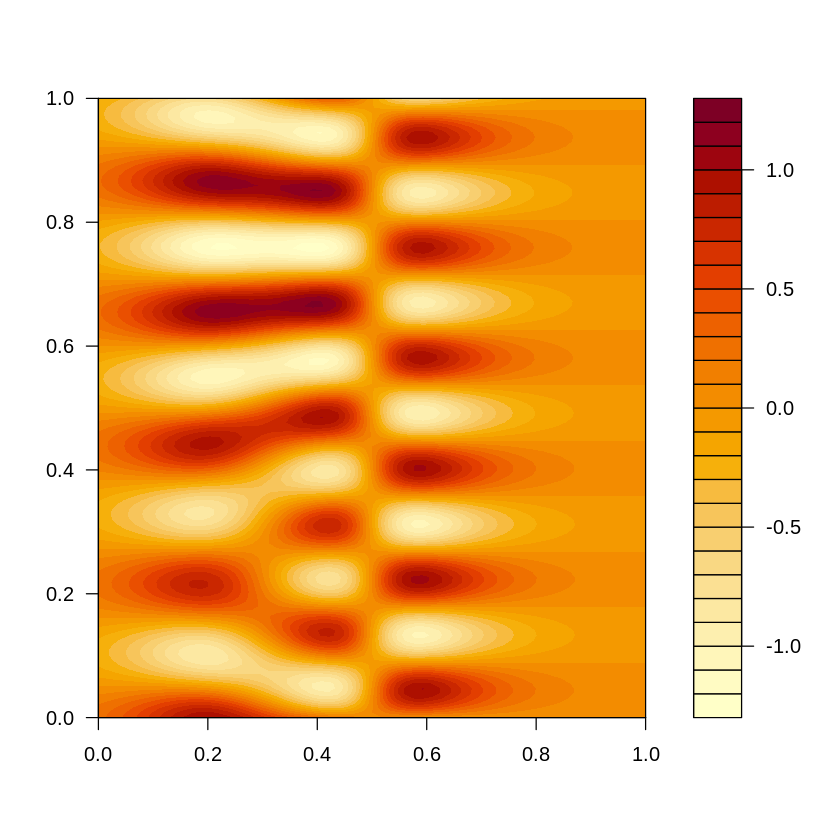

In [6]:
filled.contour(X)

And now the data with noise.

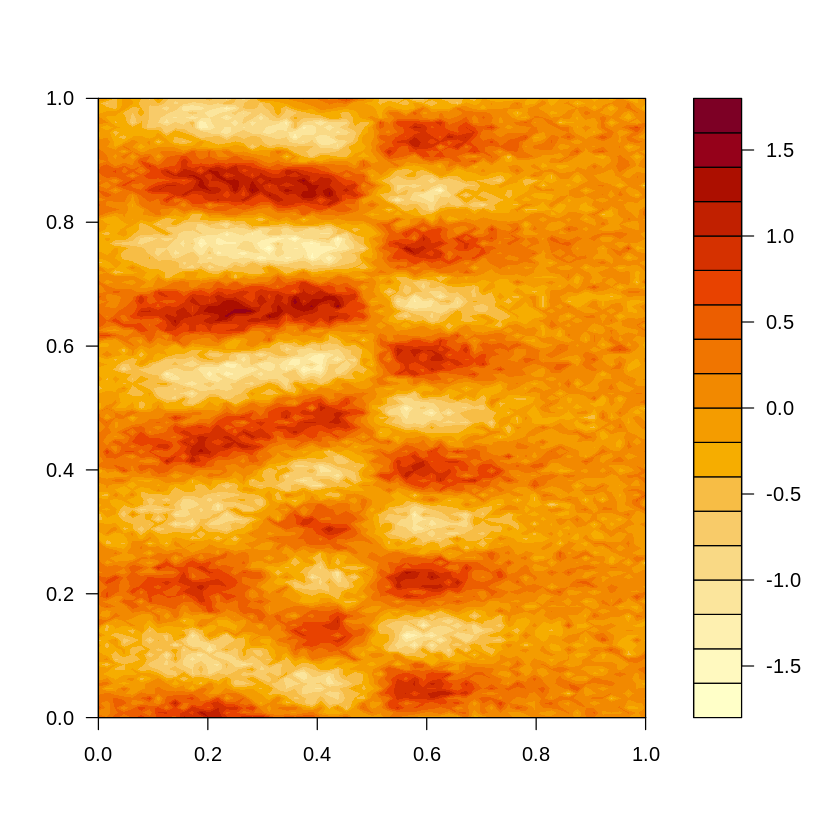

In [7]:
filled.contour(Xn)

Let's run DMD and use plots to look at the DMD modes, underlying dynamics, and eigenvalues. To run DMD, we can use the `dmd()` function. Here we will use a SVD rank of 4.

In [8]:
X.dmd = dmd(X, svd.rank = 4)

We can use `plot_modes()` to look at the DMD modes.

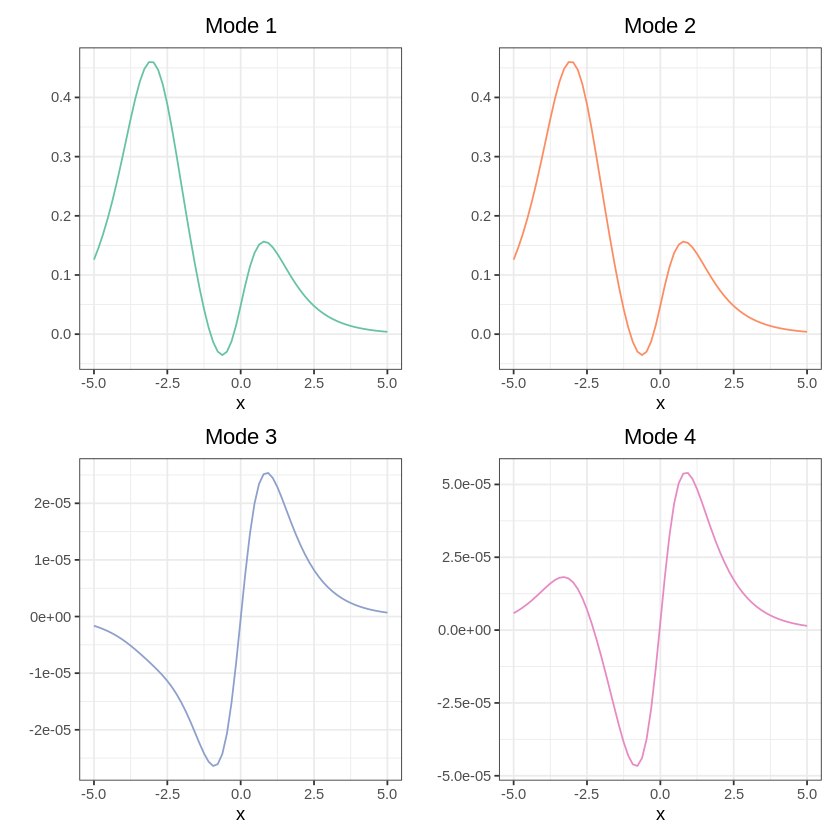

In [9]:
plot_modes(X.dmd, x)

We can use `plot_dynamics()` to look at the underlying dynamics of the DMD modes.

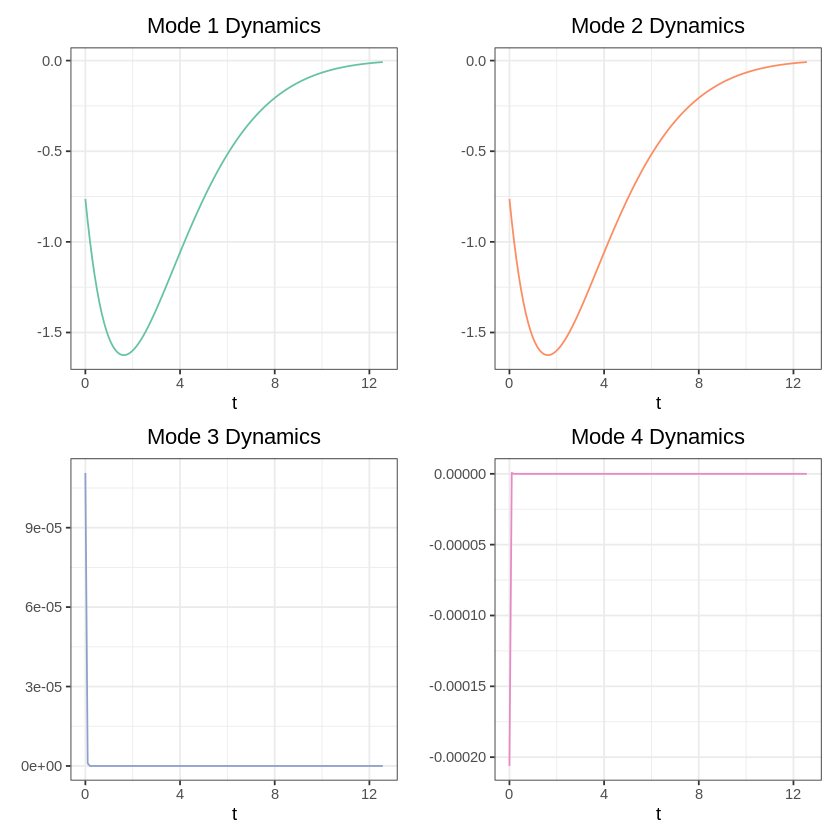

In [10]:
plot_dynamics(X.dmd, t)

We can use `plot_eigs_discrete()` to see a plot of the DMD eigenvalues in the complex plane.

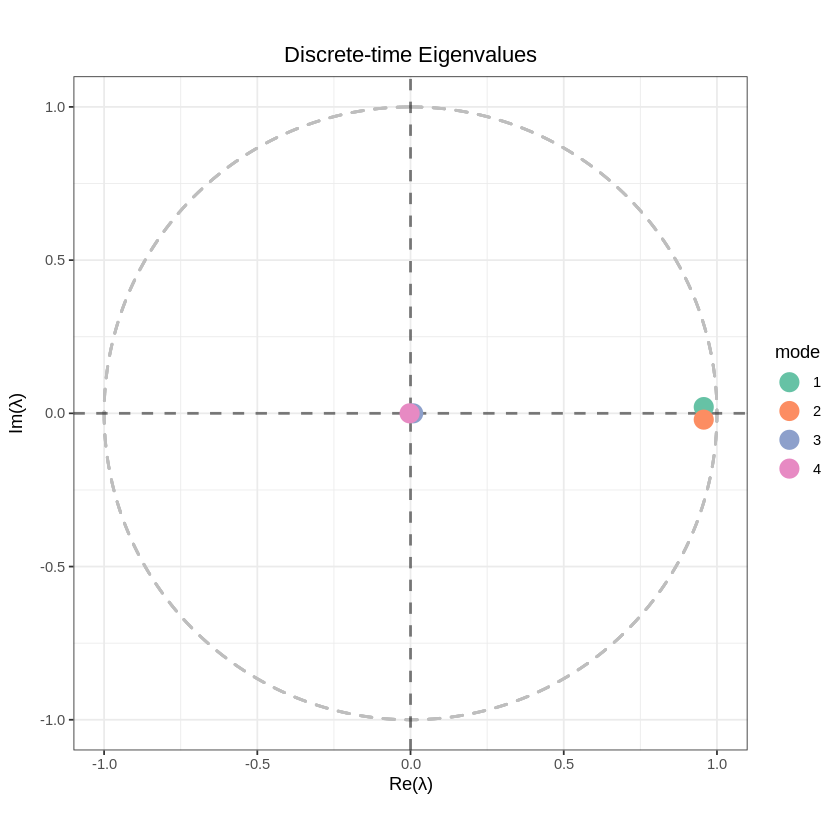

In [11]:
plot_eigs_discrete(X.dmd)

Finally, we can see a summary of all plots using the `plot_sum()` function.

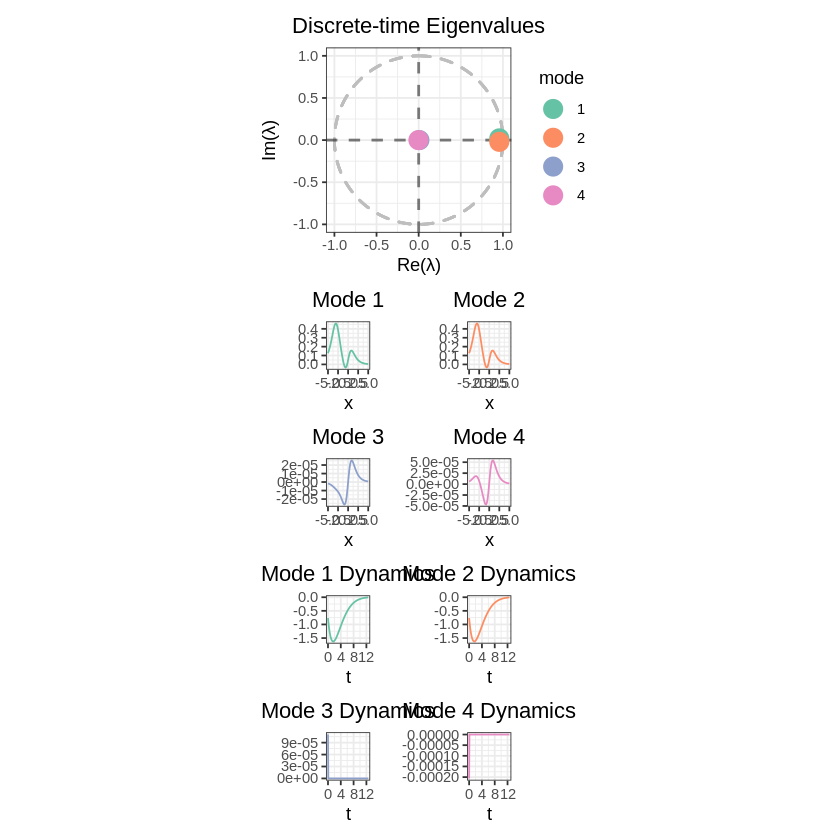

In [12]:
plot_sum(X.dmd, x, t)

The `plot_sum()` function uses the `ggplot2` library, which prints plots to the screen at a fixed aspect ratio. This works well for individual plots, but when we have a large SVD rank or want to look at the summary in detail, it's nice to see the plot on a larger scale. Let's call `plot_sum` again with `save=TRUE` to save the plot as a .png file.

In [13]:
plot_sum(X.dmd, x, t, save=TRUE)

The `plot_modes()`,`plot_dynamics()` and `plot_sum()` functions plot real values by default. We can specify what values we want plotted by setting `complex.part` equal to `real` (default), `magnitude`, `imaginary`, or `phase`.

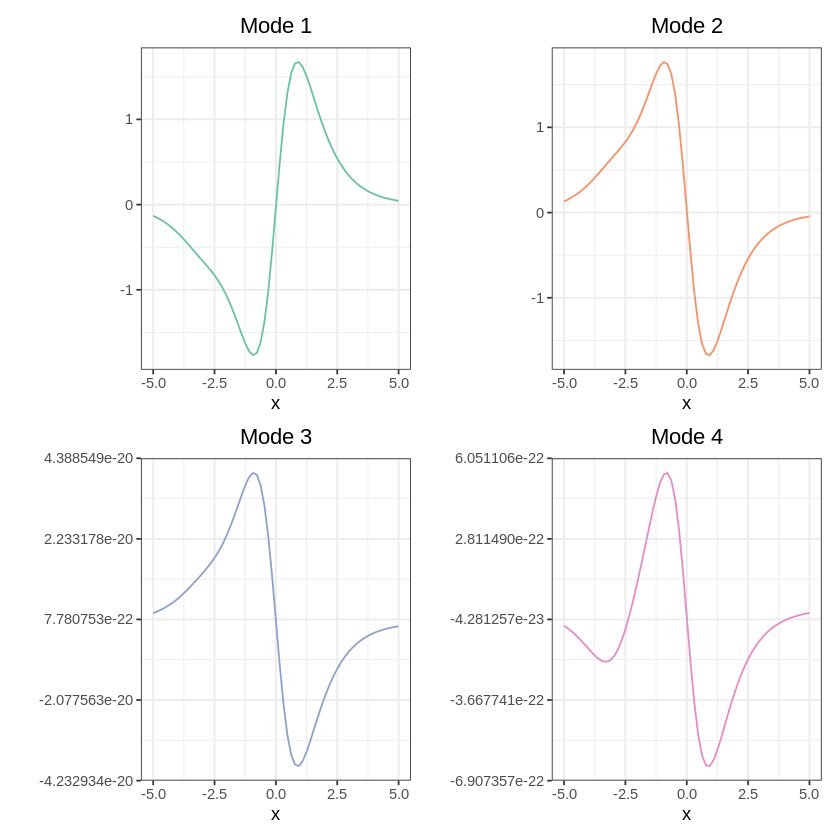

In [14]:
plot_modes(X.dmd, x, complex.part="imaginary")

Let's quickly take a look at how noise effects the DMD modes and underlying dynamics.

In [15]:
Xn.dmd = dmd(Xn, svd.rank = 4)
plot_sum(Xn.dmd, x, t, save = TRUE)

Now let's take a look at the reconstructed version of our data using DMD. Since our data reconstruction may contain imaginary values, I've created the `plot_contour()` function which has the same `complex.part` and `save` arguments as the other plot functions to plot our reconstructed matrix using the ggplot2 library.

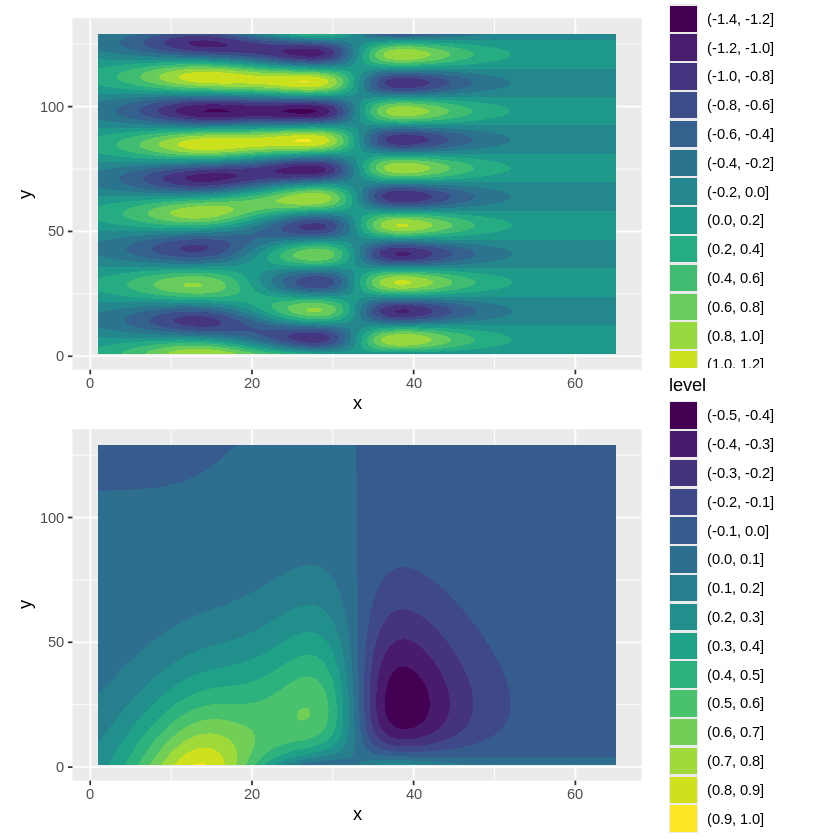

In [16]:
X.reconst = dmd_reconst(X.dmd)
plot_contour(X) / plot_contour(X.reconst) # to compare with the original data

As you can see, DMD did not do a very good job of recreating the data. This is a common pitfall of DMD and is our motivation for DMD variations such as extended DMD (eDMD) and multi-resolution DMD (mrDMD).